In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

In [4]:
sc.settings.verbosity = 2
sc.settings.set_figure_params(facecolor=None, vector_friendly=True)
sc.settings._vector_friendly = False

In [5]:
plt.rcParams["axes.grid"] = False

In [6]:
adata = sc.read_h5ad("data/adata_full_harmony_integration.h5ad")
adata.X.max()

8.382546252564728

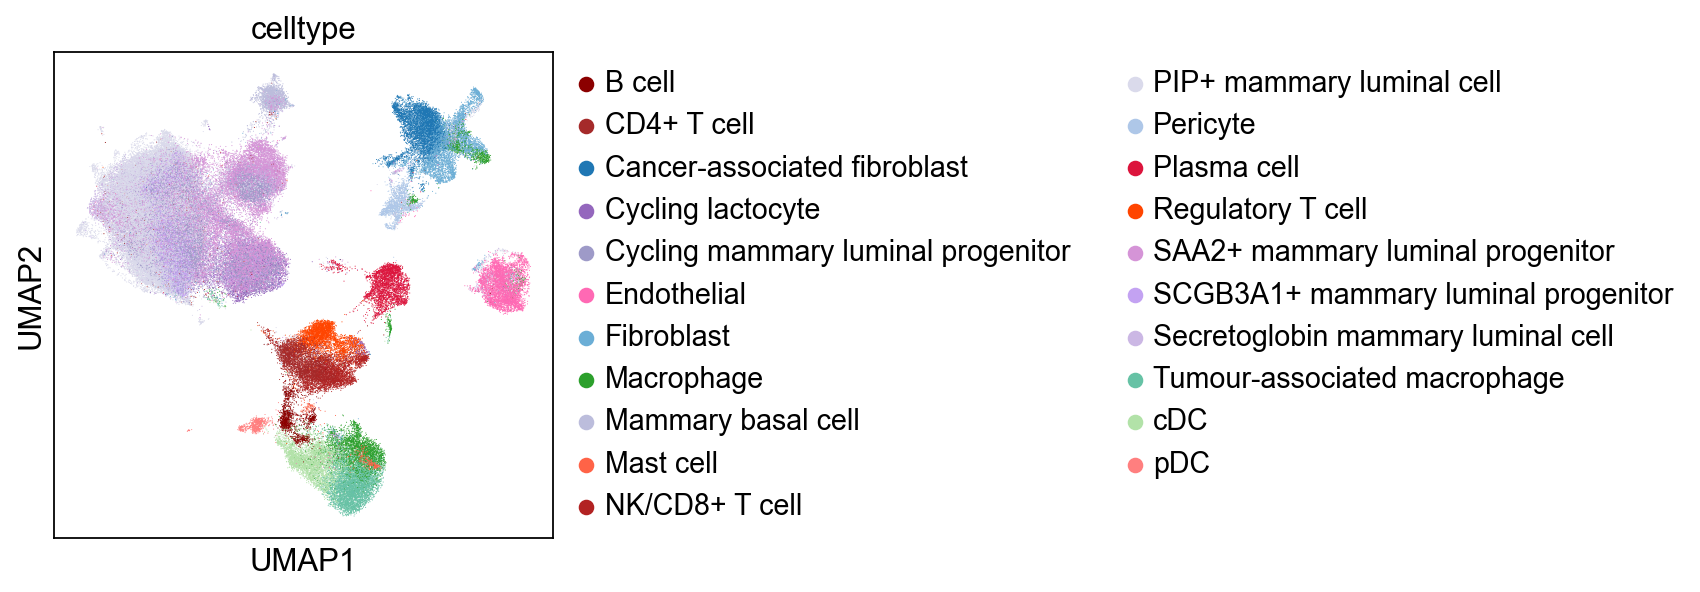

In [7]:
sc.pl.umap(
    adata,
    color="celltype",
    save="_celltype.pdf"
)

In [8]:
# scale and store results in layer
adata.layers["scaled"] = sc.pp.scale(adata, copy=True).X

In [46]:
celltype_markers = [
    "CD79A", "MS4A1",          # B cell
    "CD3D", "CD4",             # CD4+ T cell
    "COL1A1", "ACTA2",         # Cancer-associated fibroblast (myCAF-leaning)
    "TOP2A", "MKI67",           # Cycling lactocyte
    "KRT8", "ELF5",           # Cycling luminal progenitor
    "PECAM1", "VWF",           # Endothelial
    "DCN", "COL1A2",           # Fibroblast
    "CD163", "CST3",             # Macrophage
    "KRT5", "KRT14",           # Mammary basal cell
    "TPSAB1", "KIT",           # Mast cell
    "NKG7", "CD8A",            # NK / CD8+ T cell
    "PIP", "KRT18",            # Mature luminal cell
    "RGS5", "PDGFRB",          # Pericyte
    "MZB1", "JCHAIN",            # Plasma cell
    "FOXP3", "IL2RA",          # Regulatory T cell
    "SAA2", "KRT19",           # SAA2+ luminal progenitor
    "SCGB3A1", "KRT19",        # SCGB3A1+ luminal progenitor
    "SCGB1D2", "KRT18",        # Secretoglobin luminal cell
    "APOE", "C1QC",            # Tumour-associated macrophage
    "FCER1A", "CLEC10A",       # cDC
    "GZMB", "IRF7"             # pDC
]


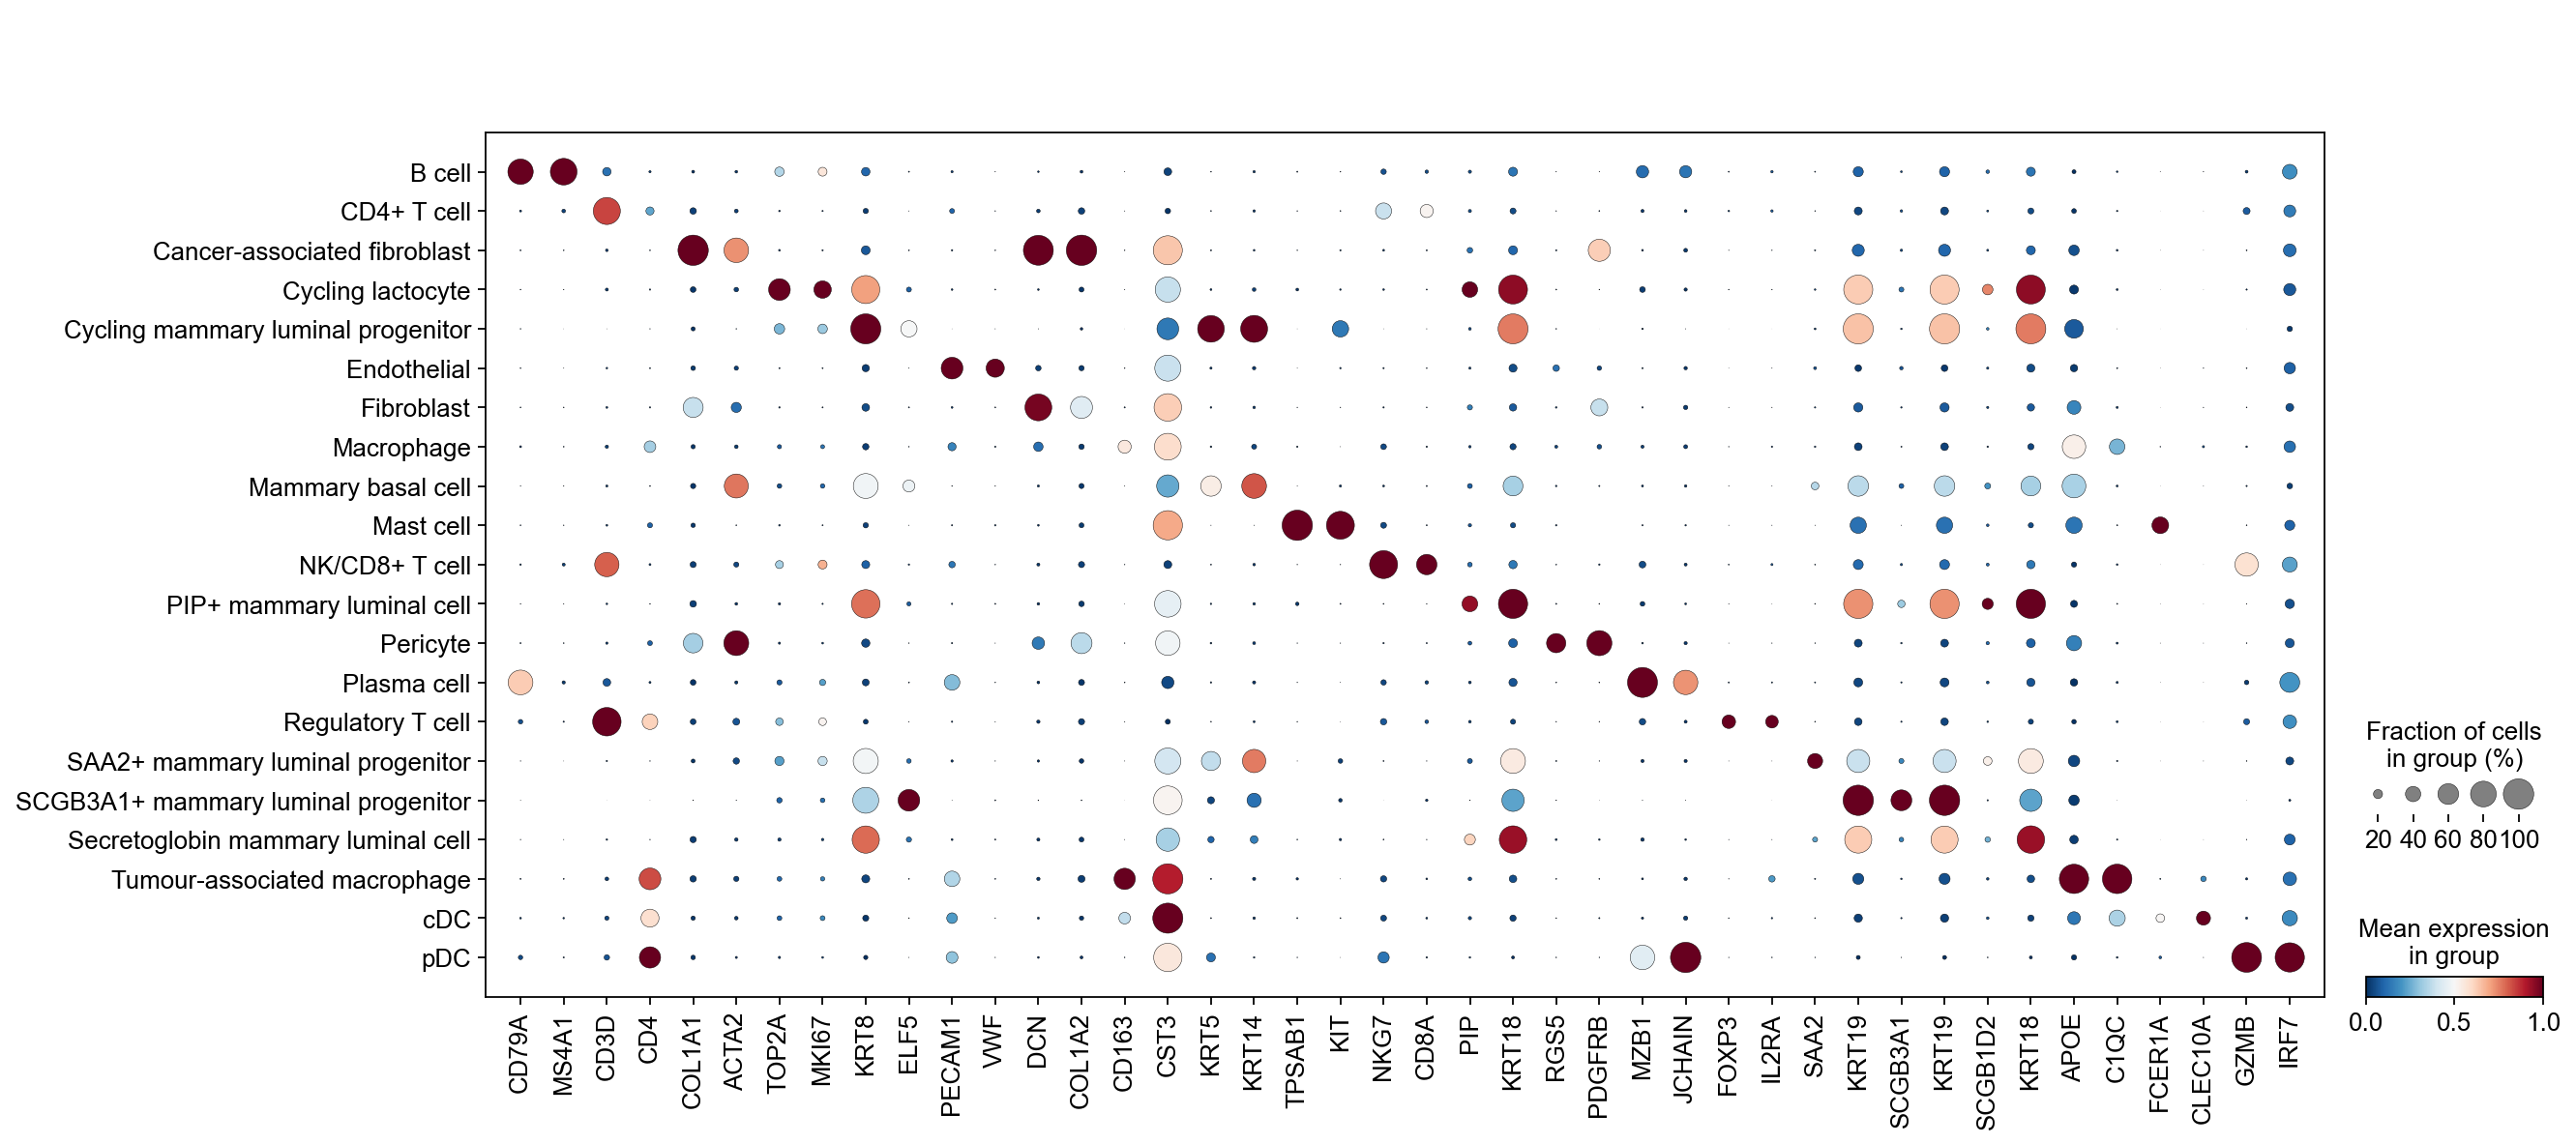

In [48]:
sc.pl.dotplot(
    adata,
    var_names=celltype_markers,
    groupby="celltype",
    standard_scale="var",
    cmap="RdBu_r",
    save="celltype_markers.pdf"
)

In [11]:
keep = ["IMM", "FIB", "EC"]
adata = adata[adata.obs["cellclass"].isin(keep)].copy()

In [12]:
adata.X = adata.layers["counts"].copy()

sc.pp.filter_genes(adata, min_cells=20)
sc.pp.normalize_total(adata, target_sum=1e4)
adata.X = np.log1p(adata.X)

filtered out 2207 genes that are detected in less than 20 cells
normalizing counts per cell
    finished (0:00:00)


In [13]:
ligands = [
    "TNF",
    "IFNG",
    "TGFB1",
    "LIF",
    "TNFSF12",
    "OSM",
    "CXCL12",
    "CCL5",
    "FGF7",
    "AREG",
    "HBEGF",
    "EREG",
    "ANGPTL2",
    "ANGPTL4",
    "ADAM17",
    "TNC",
    "MMP9",
    "JAM2",
    "CD44",
    "CD7",
    "CD99",
    "IFITM1",
    "S100A4",
    "S100B",
]

In [14]:
# scale and store results in layer
adata.layers["scaled"] = sc.pp.scale(adata, copy=True).X

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_celltype']`


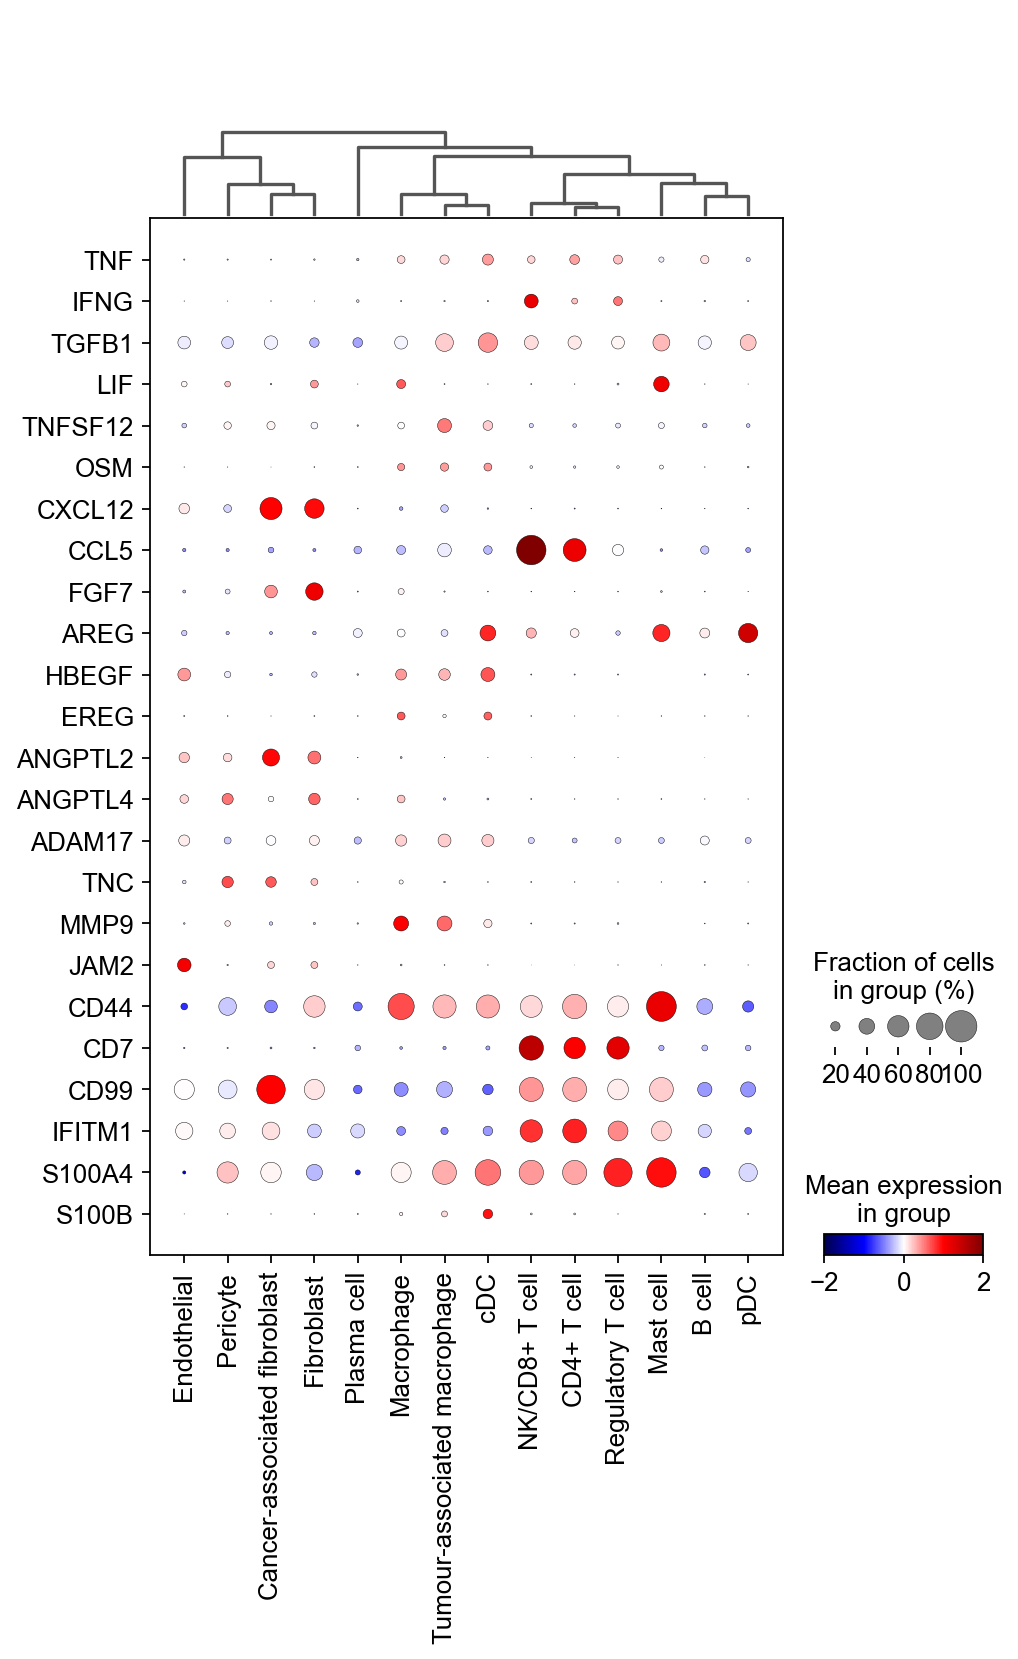

In [15]:
sc.pl.dotplot(
    adata,
    ligands,
    "celltype",
    dendrogram=True,
    layer="scaled",
    vmin=-2,
    vmax=2,
    cmap="seismic",
    swap_axes=True,
    save="nichenet_ligand_expression_g0.pdf"
)

In [16]:
ligands = [
    "AREG",
    "GRN",
    "IGF1",
    "ANGPTL4",
    "LAMA4",
    "TIMP3",
    "S100A4",
    "COL8A1",
    "NECTIN2",
    "CD6",
    "TIGIT",
    "HLA-DRB1",
    "CD44",
    "BACE2",
    "ADAM12",
    "PSEN1",
    "ADAM15",
    "GPC3",
    "IFITM1"
]

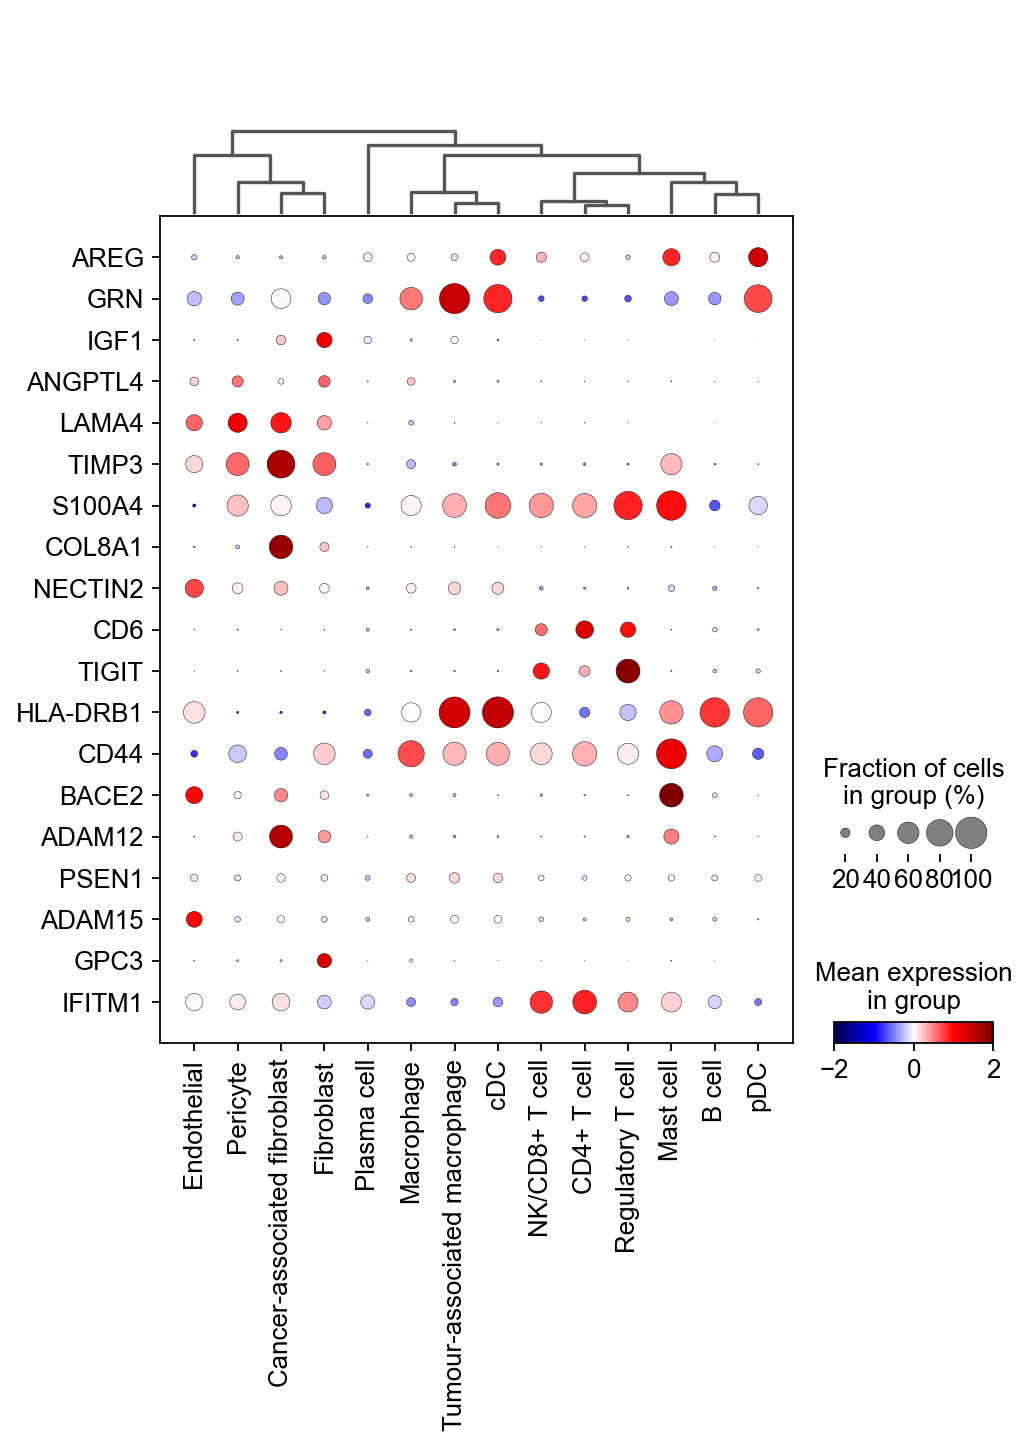

In [17]:
sc.pl.dotplot(
    adata,
    ligands,
    "celltype",
    dendrogram=True,
    layer="scaled",
    vmin=-2,
    vmax=2,
    cmap="seismic",
    swap_axes=True,
    save="nichenet_ligand_expression_fast.pdf",
)